all 763291
day 1+ 756541
day1+, cold starts: 18166


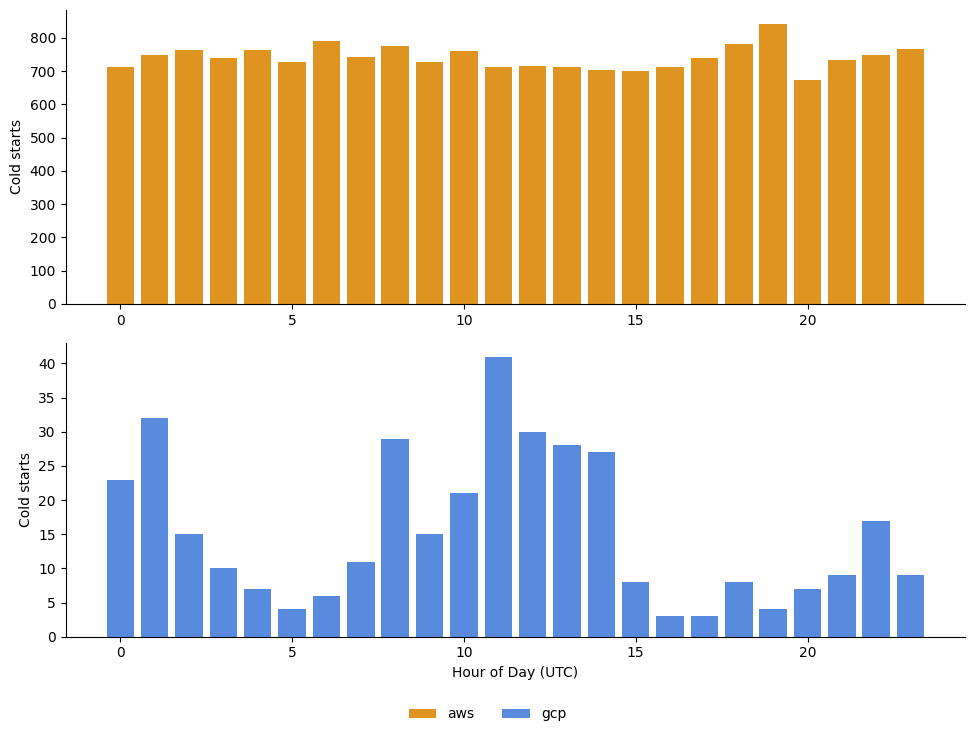

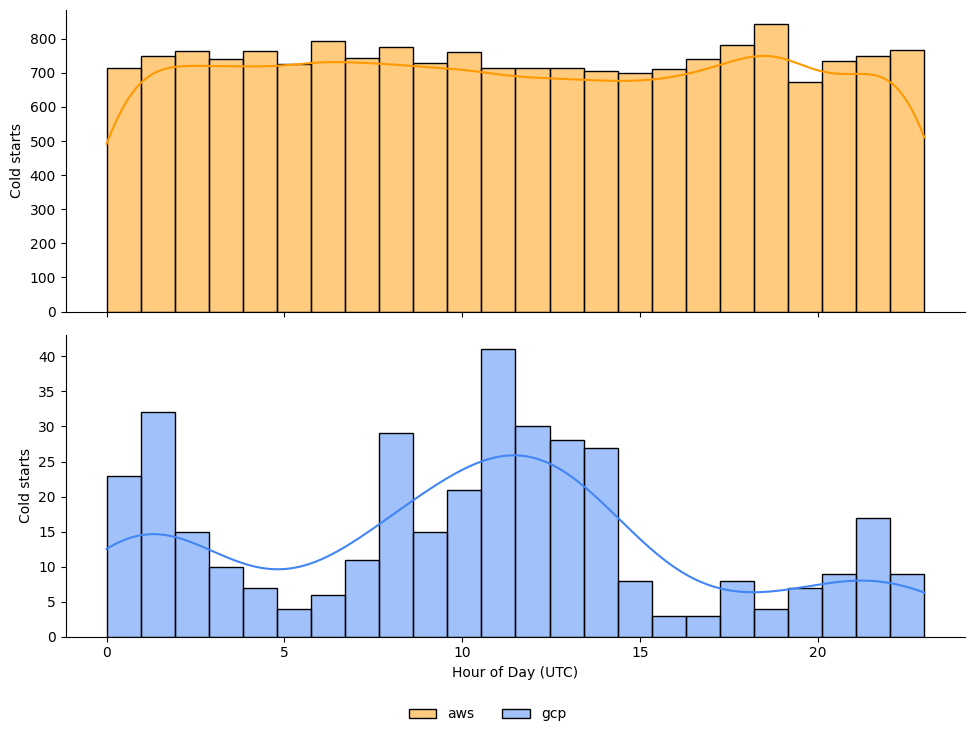

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.reset_defaults()
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
df = pd.read_pickle('../stats-all-latest.pkl')
print('all', len(df))

# Day 1+
data = df.loc[(df["timestamp"] > 1733184000000)].copy()
data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()
data["dom"] = data.index.day
data["dow"] = data.index.day_of_week
data["day_name"] = data.index.day_name()
data["hod"] = data.index.hour
data["moh"] = data.index.minute
data["how"] = data["dow"] * 24 + data["hod"]
data["msm"] = data.index.hour * 60 + (data.index.minute)
print('day 1+', len(data))

# Cold starts only
coldStarts = data.dropna(subset=['coldStart'])
print('day1+, cold starts:', len(coldStarts))

# Create the catplot with 'providerName' as row and hue
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='hod',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex='row',
    sharey=False,
)
sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
# g.set(xticks=range(0, 24, 6))
g.set_titles('')
g.set_xlabels('Hour of Day (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Hour of Day (UTC)')
plt.tight_layout()
plt.show()

g = sns.displot(
    data=coldStarts,
    x="hod",
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    # col="time",
    kde=True,
    facet_kws={'sharey': False},
)
sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
# g.set(xticks=range(0, 24, 6))
g.set_titles('')
g.set_xlabels('Hour of Day (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Hour of Day (UTC)')
plt.tight_layout()
plt.show()


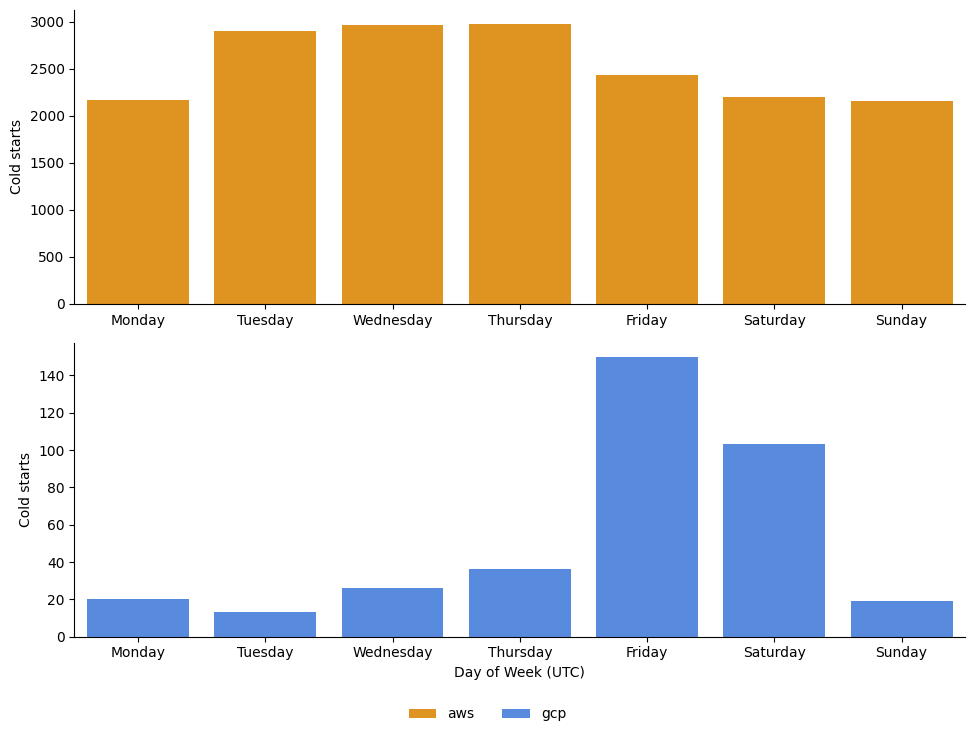

In [2]:
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='day_name',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex=False,
    sharey=False,
)
sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set_titles('')
g.set_xlabels('Day of Week (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Day of Week (UTC)')
plt.tight_layout()
plt.show()

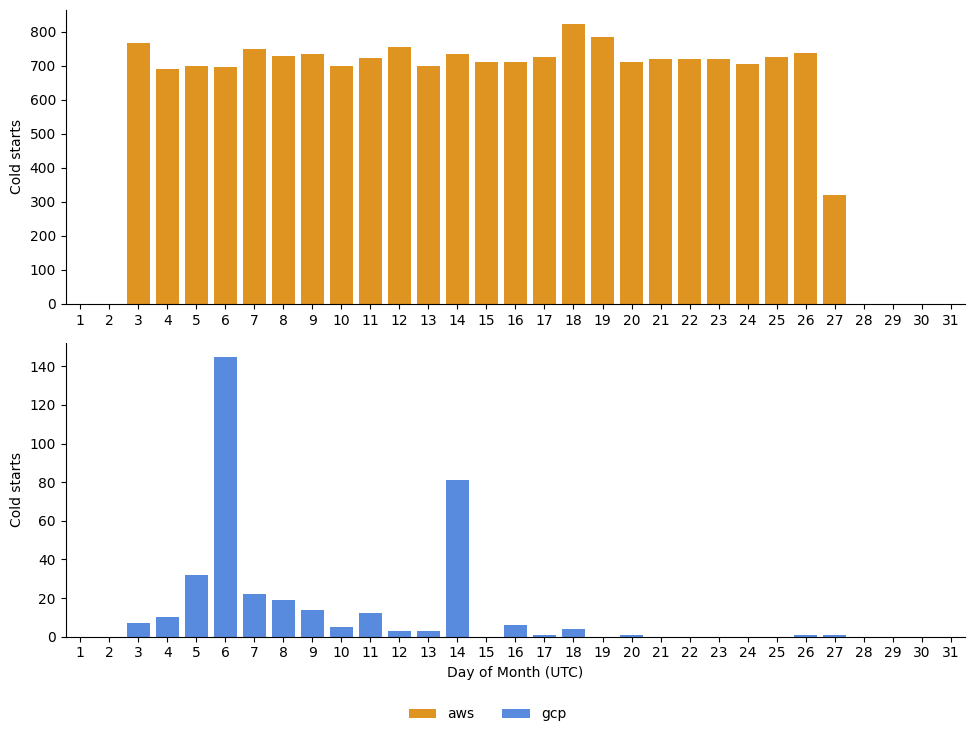

In [3]:
g = sns.catplot(
    data=coldStarts,
    kind='count',
    x='dom',
    hue='providerName',   # Keep providerName for color differentiation
    row='providerName',   # Separate rows for each provider
    palette=colors,       # Use the defined colors
    aspect=2.5,
    height=3.5,
    native_scale=True,
    sharex=False,
    sharey=False,
)

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=2)
g.set(xticks=range(0, 32, 1), xlim=(0.5, 31.5))
g.set_titles('')
g.set_xlabels('Day of Month (UTC)')
g.set_ylabels('Cold starts')
# plt.suptitle('Cold starts by Day of Month (UTC)')
plt.tight_layout()
plt.show()

756541
121243 landscape


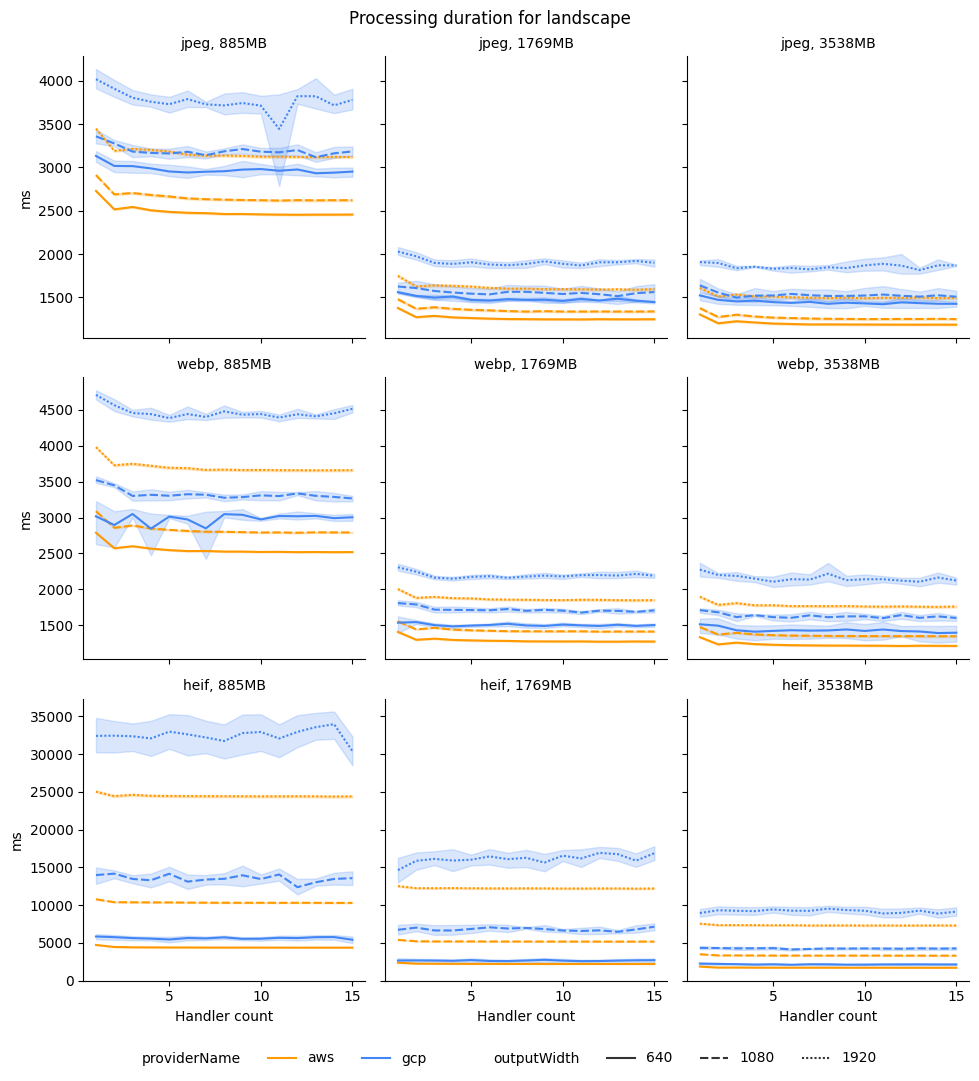

120105 portrait


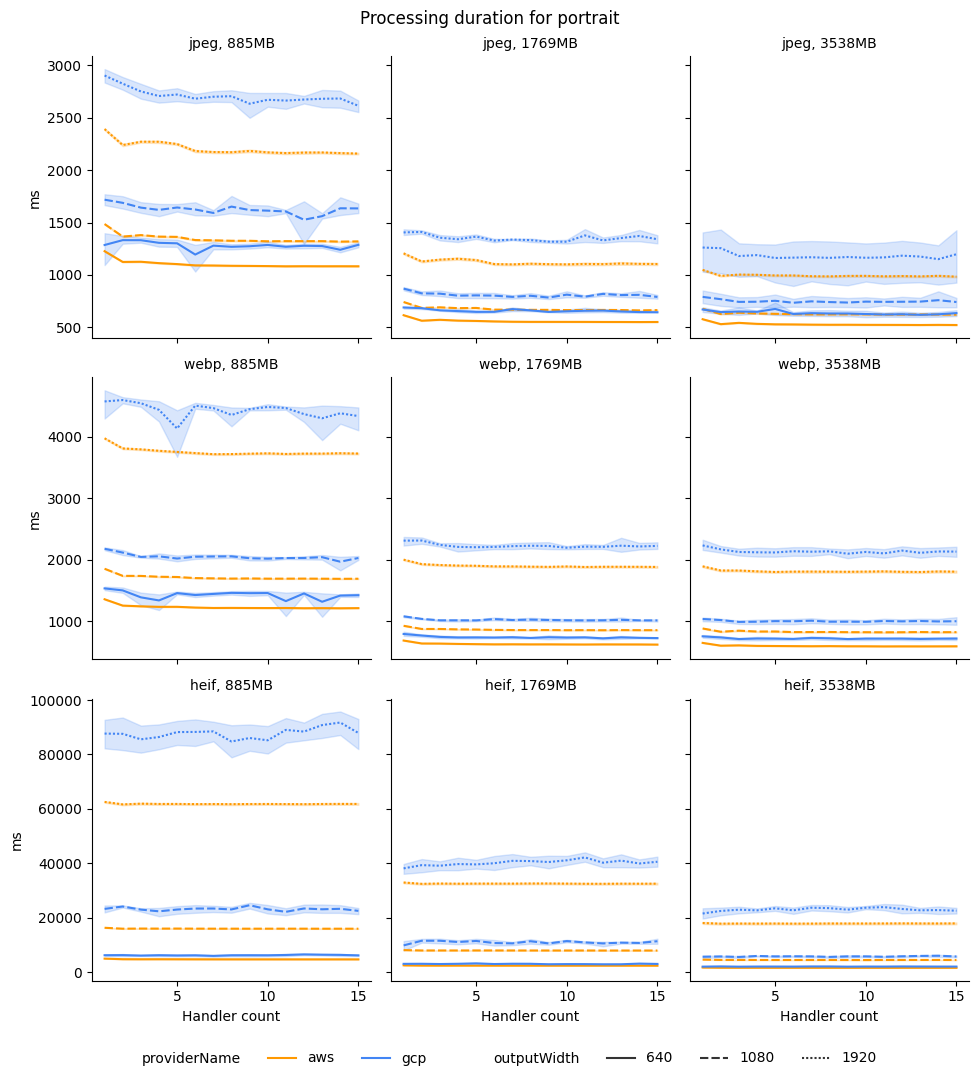

In [10]:
print(len(data))
for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName) & (data['handlerCount'] < 16)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='handlerCount',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        facet_kws={'sharey': 'row'},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Handler count')
    g.set_ylabels('ms')
    # [ax.set(xlabel='handlerCounterrr') for sublist in g.axes for ax in sublist] , use with facet_kws={'sharex': False, 'sharey': 'row'}, for relplot
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

8807 aws


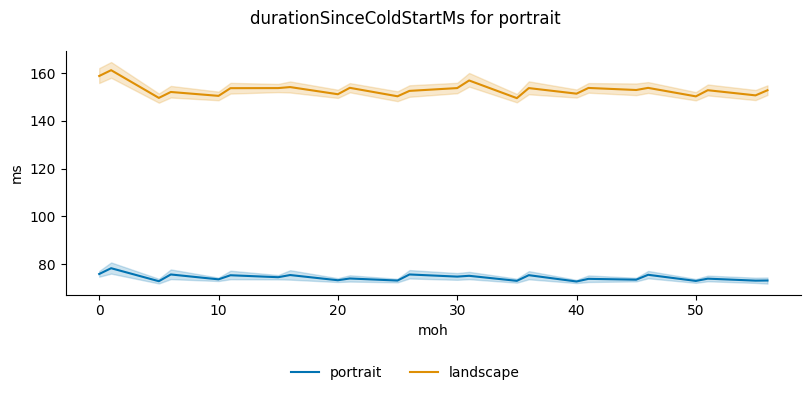

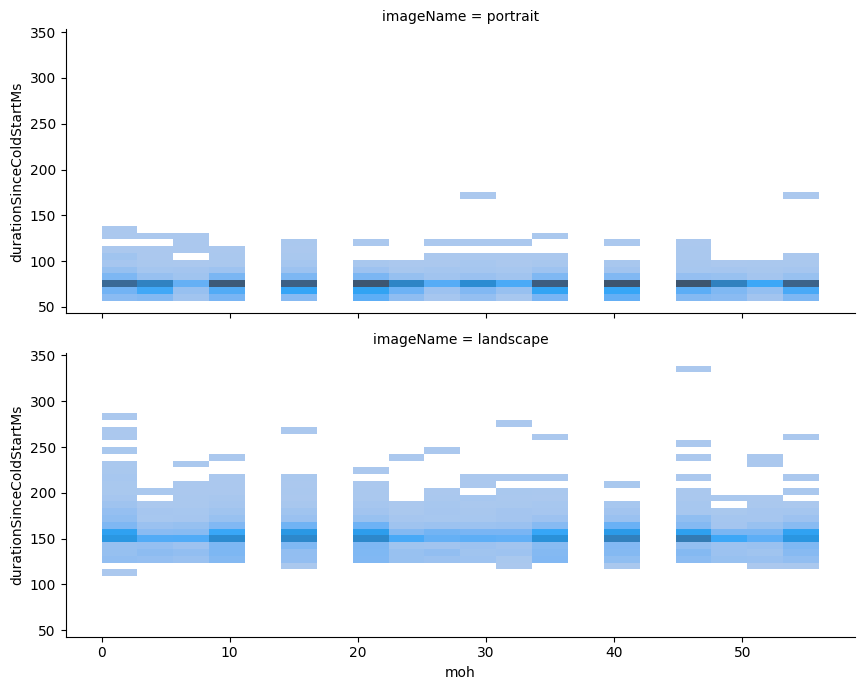

7 gcp


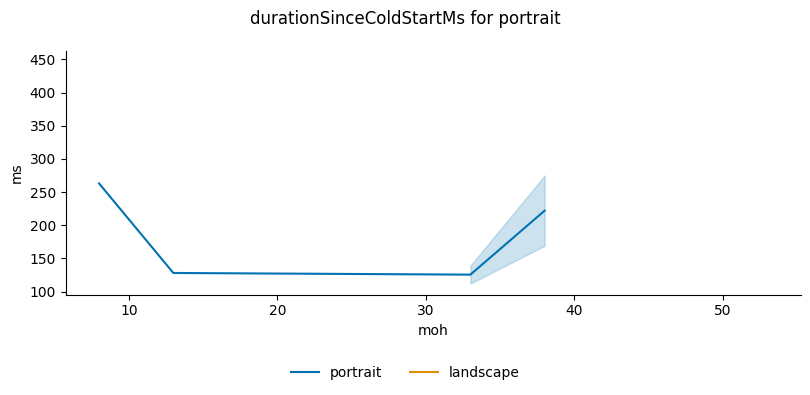

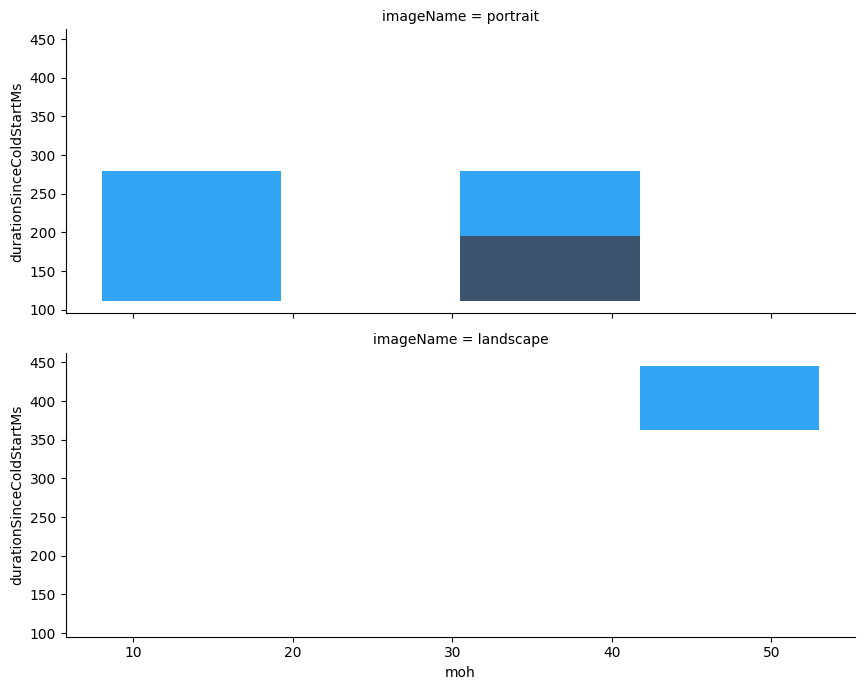

In [11]:
# plot cold start duration (y=durationSinceColdStartMs) by hour of day (hod)
from IPython.display import display, HTML

# print(len(coldStarts))
# display(HTML(data.head(100).to_html()))
# remove entries in data with handlerCount >5
firstExecutions = data[data['handlerCount'] <= 1]
firstExecutions = firstExecutions[firstExecutions['durationSinceColdStartMs'] <= 1200]
# display(HTML(result.head(100).to_html()))


# for imageName in ["landscape", "portrait"]:
for providerName in ['aws', 'gcp']:
    # data2 = firstExecutions.loc[(firstExecutions["imageName"] == imageName) & (firstExecutions['providerName'] == 'aws')]
    data2 = firstExecutions.loc[(firstExecutions['providerName'] == providerName)]
    print(len(data2), providerName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='moh',
        y='durationSinceColdStartMs',
        hue='imageName',   # Keep providerName for color differentiation
        # palette=colors,       # Use the defined colors
        palette='colorblind',       # Use the defined colors
        # row='outputFormat',   # Separate rows for each provider
        # col='providerMemoryAssociated',
        # style='',
        # row_order=['jpeg', 'webp', 'heif'],
        aspect=2,
        height=3.5,
        # facet_kws={'sharey': 'row'},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    # g.set_titles("{row_name}, {col_name}MB")
    # g.set_xlabels('Hour of Day (UTC)')
    g.set_ylabels('ms')
    # [ax.set(xlabel='handlerCounterrr') for sublist in g.axes for ax in sublist] , use with facet_kws={'sharex': False, 'sharey': 'row'}, for relplot
    plt.suptitle(f'durationSinceColdStartMs for {imageName}')
    plt.tight_layout()
    plt.show()

    g = sns.displot(
        data=data2,
        x="moh",
        y='durationSinceColdStartMs',
        # hue='imageName',   # Keep providerName for color differentiation
        row='imageName',   # Separate rows for each provider
        # palette=colors,       # Use the defined colors
        aspect=2.5,
        height=3.5,
        # col="time",
        # kde=True,
        facet_kws={'sharey': False},
    )
    plt.show()
